## Reinforcement learning

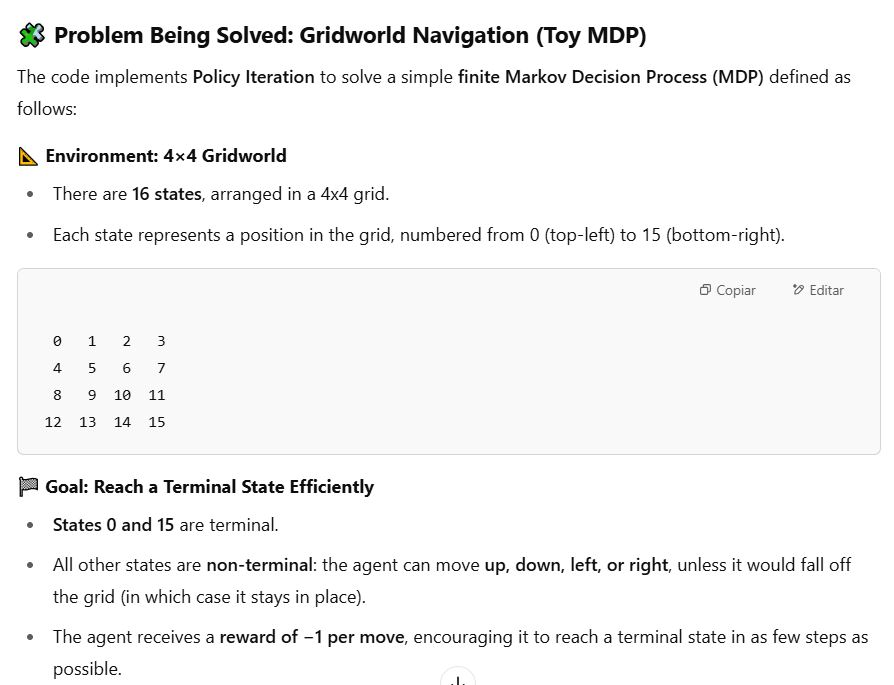

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Grid and MDP settings
grid_size = 4
num_states = grid_size * grid_size
num_actions = 4  # up, down, left, right
gamma = 0.9
theta = 1e-4

# Actions: up, down, left, right
actions = {0: -grid_size, 1: grid_size, 2: -1, 3: 1}
action_symbols = ['↑', '↓', '←', '→']
action_arrows = {0: (0, -1), 1: (0, 1), 2: (-1, 0), 3: (1, 0)}

def is_valid(state, action):
    row, col = divmod(state, grid_size)
    if action == 0 and row == 0: return False
    if action == 1 and row == grid_size - 1: return False
    if action == 2 and col == 0: return False
    if action == 3 and col == grid_size - 1: return False
    return True

def step(state, action):
    if state == 0 or state == num_states - 1:
        return state, 0  # terminal state: no cost after reaching
    if not is_valid(state, action):
        return state, -1
    next_state = state + actions[action]
    if next_state in [0, num_states - 1]:
        return next_state, 0  # entering terminal state: stop cost
    return next_state, -1

# Initialization
policy = np.zeros(num_states, dtype=int)
V = np.zeros(num_states)

# Policy Iteration
iteration = 0
is_policy_stable = False
while not is_policy_stable:
    print(f"\n=== Policy Iteration {iteration} ===")

    # Policy Evaluation
    while True:
        delta = 0
        new_V = np.copy(V)
        for s in range(num_states):
            if s in [0, num_states - 1]:
                continue
            a = policy[s]
            next_s, reward = step(s, a)
            new_V[s] = reward + gamma * V[next_s]
            delta = max(delta, abs(V[s] - new_V[s]))
        V = new_V
        print(V)
        print(f"  Δ = {delta:.5f}")
        if delta < theta:
            break

    # Policy Improvement
    is_policy_stable = True
    for s in range(num_states):
        if s in [0, num_states - 1]:
            continue
        old_action = policy[s]
        action_values = []
        for a in range(num_actions):
            if not is_valid(s, a):
                action_values.append(-float('inf'))
            else:
                next_s, reward = step(s, a)
                action_values.append(reward + gamma * V[next_s])
        best_action = np.argmax(action_values)
        policy[s] = best_action
        if old_action != best_action:
            is_policy_stable = False

    # Print policy
    print("  Policy:")
    for r in range(grid_size):
        row = ''
        for c in range(grid_size):
            s = r * grid_size + c
            row += ' T ' if s in [0, num_states - 1] else f" {action_symbols[policy[s]]} "
        print(row)

    iteration += 1



=== Policy Iteration 0 ===
[ 0. -1. -1. -1.  0. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.  0.]
  Δ = 1.00000
[ 0.  -1.9 -1.9 -1.9  0.  -1.9 -1.9 -1.9 -1.  -1.9 -1.9 -1.9 -1.9 -1.9
 -1.9  0. ]
  Δ = 0.90000
[ 0.   -2.71 -2.71 -2.71  0.   -2.71 -2.71 -2.71 -1.   -2.71 -2.71 -2.71
 -1.9  -2.71 -2.71  0.  ]
  Δ = 0.81000
[ 0.    -3.439 -3.439 -3.439  0.    -3.439 -3.439 -3.439 -1.    -3.439
 -3.439 -3.439 -1.9   -3.439 -3.439  0.   ]
  Δ = 0.72900
[ 0.     -4.0951 -4.0951 -4.0951  0.     -4.0951 -4.0951 -4.0951 -1.
 -4.0951 -4.0951 -4.0951 -1.9    -4.0951 -4.0951  0.    ]
  Δ = 0.65610
[ 0.      -4.68559 -4.68559 -4.68559  0.      -4.68559 -4.68559 -4.68559
 -1.      -4.68559 -4.68559 -4.68559 -1.9     -4.68559 -4.68559  0.     ]
  Δ = 0.59049
[ 0.       -5.217031 -5.217031 -5.217031  0.       -5.217031 -5.217031
 -5.217031 -1.       -5.217031 -5.217031 -5.217031 -1.9      -5.217031
 -5.217031  0.      ]
  Δ = 0.53144
[ 0.        -5.6953279 -5.6953279 -5.6953279  0.        -5.6953279
 -5.69

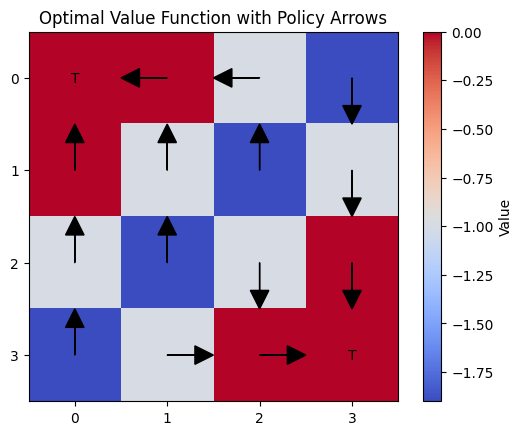

In [5]:
# Visualization
def plot_policy_and_value(V, policy):
    fig, ax = plt.subplots()
    V_grid = V.reshape((grid_size, grid_size))
    policy_grid = policy.reshape((grid_size, grid_size))

    ax.imshow(V_grid, cmap='coolwarm', interpolation='nearest')
    ax.set_title("Optimal Value Function with Policy Arrows")
    ax.set_xticks(np.arange(grid_size))
    ax.set_yticks(np.arange(grid_size))

    for r in range(grid_size):
        for c in range(grid_size):
            s = r * grid_size + c
            if s in [0, num_states - 1]:
                ax.text(c, r, 'T', ha='center', va='center', color='black')
                continue
            dx, dy = action_arrows[policy[s]]
            ax.arrow(c, r, dx * 0.3, dy * 0.3, head_width=0.2, head_length=0.2, fc='black')

    plt.gca().invert_yaxis()
    plt.colorbar(ax.imshow(V_grid, cmap='coolwarm'), label='Value')
    plt.show()

plot_policy_and_value(V, policy)